## Running kinGEMs Pipeline on $E. coli$ core Model

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('distributed').setLevel(logging.ERROR)
try:
    import gurobipy
    gurobipy.setParam('OutputFlag', 0)
except ImportError:
    pass
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import cobra # type: ignore
import numpy as np # type: ignore
from datetime import datetime
import random
from cobra.io import write_sbml_model # type: ignore
import cobra as cb

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import load_model, convert_to_irreversible, prepare_model_data, retrieve_sequences, map_metabolites, merge_substrate_sequences, process_merged_data_with_folds, process_kcat_predictions, assign_kcats_to_model, format_kcats_like_gpr, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.modeling.tuning import simulated_annealing, analyze_kcat_changes
from kinGEMs.modeling.fva import flux_variability_analysis, plot_flux_variability, plot_cumulative_fvi_distribution, flux_variability_analysis_parallel


Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25


2025-09-05 11:29:19.570 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2


### Set your GEM name here

### Set your GEM name here

In [2]:
# === Configuration ===
organism_strain_GEMname = "ecoli_core" # Update this
organism = "E coli" # Update this 
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}_{random.randint(1000, 9999)}"

# Directories
data_dir = "../data"
raw_data_dir = os.path.join(data_dir, "raw")
interim_data_dir = os.path.join(data_dir, "interim")
interim_data_dir_spec = os.path.join(interim_data_dir, f"{organism_strain_GEMname}")
processed_data_dir = os.path.join(data_dir, "processed")
processed_data_dir_spec = os.path.join(processed_data_dir, f"{organism_strain_GEMname}")
CPIPred_data_dir = os.path.join(interim_data_dir, "CPI-Pred predictions")
results_dir = os.path.join(os.getcwd(), "results")
tuning_results_dir = os.path.join(results_dir, "tuning_results", run_id)
os.makedirs(tuning_results_dir, exist_ok=True)

# Input files
model_path = os.path.join(raw_data_dir, "e_coli_core.xml") # Update this
predictions_csv_path = os.path.join(CPIPred_data_dir, f"X06A_kinGEMs_{organism_strain_GEMname}_predictions.csv")

# Output files
substrates_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_substrates.csv")
sequences_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_sequences.csv")
merged_data_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_merged_data.csv")
processed_data_output = os.path.join(processed_data_dir_spec, f"{organism_strain_GEMname}_processed_data.csv")

# Simulation parameters
biomass_reaction = 'BIOMASS_Ecoli_core_w_GAM' # Update this
enzyme_upper_bound = 0.125

### Step 1: Preparing and processing model data

In [3]:
print("=== Step 1: Preparing model data ===")
model, substrate_df, sequences_df = prepare_model_data(
    model_path=model_path,
    substrates_output=substrates_output,
    sequences_output=sequences_output,
    organism=organism
)

=== Step 1: Preparing model data ===
Loaded model with 95 reactions and 72 metabolites
Extracted 264 substrate-reaction-direction pairs


2025-09-05 11:29:41,102 - kinGEMs.dataset - INFO - There are 71 substrates in the GEM.
2025-09-05 11:29:41,137 - kinGEMs.dataset - INFO - -----------------------------
2025-09-05 11:29:41,137 - kinGEMs.dataset - INFO - Mapping substrate: atp_c
2025-09-05 11:29:41,180 - kinGEMs.dataset - INFO - BiGG Name: ATP C10H12N5O13P3
2025-09-05 11:29:41,211 - kinGEMs.dataset - INFO - SMILES found in MetaNetX: Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O)([O-])OP(=O)([O-])[O-])[C@@H](O)[C@H]1O
2025-09-05 11:29:41,211 - kinGEMs.dataset - INFO - -----------------------------
2025-09-05 11:29:41,211 - kinGEMs.dataset - INFO - Mapping substrate: f6p_c
2025-09-05 11:29:41,245 - kinGEMs.dataset - INFO - BiGG Name: D-Fructose 6-phosphate
2025-09-05 11:29:41,294 - kinGEMs.dataset - INFO - SMILES found in SEED: O=P([O-])([O-])OC[C@H]1O[C@](O)(CO)[C@@H](O)[C@@H]1O
2025-09-05 11:29:41,295 - kinGEMs.dataset - INFO - -----------------------------
2025-09-05 11:29:41,295 - kinGEMs.dataset - INFO - Mapping subs

Mapped metabolites to SMILES (264 found)


2025-09-05 11:29:50,806 - root - WARNING - No sequence found for gene s0001


Retrieved 136 protein sequences


In [4]:
# Diagnostic: Print gene and reaction counts after model preparation
print("[Step] After prepare_model_data:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])

# Diagnostic: Print kcat coverage if available
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After prepare_model_data:
  Genes in model: 137
  Reactions in model: 95
  First 10 gene IDs: ['b0115', 'b2415', 'b3736', 'b2463', 'b0721', 'b2492', 'b2297', 'b0474', 'b2416', 'b2287']
  First 10 reaction IDs: ['PTAr', 'ME1', 'PGK', 'G6PDH2r', 'PIt2r', 'TALA', 'ICL', 'PYK', 'GLUN', 'ATPM']
  Reactions with kcat: 0
  Reactions without kcat: 95


### Step 2: Merging substrate and sequence data

In [5]:
print("=== Step 2: Merging substrate and sequence data ===")

# substrate_df = pd.read_csv(substrates_output)
# sequences_df = pd.read_csv(sequences_output)
# model = load_model(model_path)

merged_data = merge_substrate_sequences(
    substrate_df=substrate_df,
    sequences_df=sequences_df,
    model=model,
    output_path=merged_data_output
)

=== Step 2: Merging substrate and sequence data ===


In [6]:
# Diagnostic: After merging substrate and sequence data
print("[Step] After merge_substrate_sequences:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After merge_substrate_sequences:
  Genes in model: 137
  Reactions in model: 95
  First 10 gene IDs: ['b0115', 'b2415', 'b3736', 'b2463', 'b0721', 'b2492', 'b2297', 'b0474', 'b2416', 'b2287']
  First 10 reaction IDs: ['PTAr', 'ME1', 'PGK', 'G6PDH2r', 'PIt2r', 'TALA', 'ICL', 'PYK', 'GLUN', 'ATPM']
  Reactions with kcat: 0
  Reactions without kcat: 95


### Step 3: Processing CPI-Pred kcat values

In [7]:
print("=== Step 3: Processing CPI-Pred kcat values & annotating model ===")
processed_data = process_kcat_predictions(
    merged_df=merged_data,
    predictions_csv_path=predictions_csv_path,
    output_path=processed_data_output
)

model = annotate_model_with_kcat_and_gpr(
    model=model,
    df=processed_data
)

=== Step 3: Processing CPI-Pred kcat values & annotating model ===


In [8]:
# Diagnostic: After kcat annotation
print("[Step] After annotate_model_with_kcat_and_gpr:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After annotate_model_with_kcat_and_gpr:
  Genes in model: 137
  Reactions in model: 95
  First 10 gene IDs: ['b0115', 'b2415', 'b3736', 'b2463', 'b0721', 'b2492', 'b2297', 'b0474', 'b2416', 'b2287']
  First 10 reaction IDs: ['PTAr', 'ME1', 'PGK', 'G6PDH2r', 'PIt2r', 'TALA', 'ICL', 'PYK', 'GLUN', 'ATPM']
  Reactions with kcat: 66
  Reactions without kcat: 29


## Step 4: Optimization (FBA Sanity Check + kinGEMs)

make sure code below works first

In [9]:
print("=== Step 4: Running optimization with kcat constraints ===")
(solution_value, df_FBA, gene_sequences_dict, _)=run_optimization_with_dataframe(
    model=model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True,
    verbose=False)

print("Biomass value: ", solution_value)

=== Step 4: Running optimization with kcat constraints ===


2025-09-05 11:30:26,401 - pyomo.core - WARNING - Loading a SolverResults object with a warning status into model.name="unknown";
  - termination condition: infeasible
  - message from solver: Model was proven to be infeasible.


Biomass value:  0.8739215069684305


In [10]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 137
  Reactions in model: 95
  First 10 gene IDs: ['b0115', 'b2415', 'b3736', 'b2463', 'b0721', 'b2492', 'b2297', 'b0474', 'b2416', 'b2287']
  First 10 reaction IDs: ['PTAr', 'ME1', 'PGK', 'G6PDH2r', 'PIt2r', 'TALA', 'ICL', 'PYK', 'GLUN', 'ATPM']
  Reactions with kcat: 66
  Reactions without kcat: 29


### Step 5: Simulated Annealing

=== Step 5: Running simulated annealing ===


2025-09-05 11:30:26,816 - pyomo.core - WARNING - Loading a SolverResults object with a warning status into model.name="unknown";
  - termination condition: infeasible
  - message from solver: Model was proven to be infeasible.


Final biomass: 0.8739
Improvement: 0.0%
Top 10 enzymes by mass contribution:
    Reactions Single_gene  enzyme_mass
0       AKGDH       b0726     1.050605
1       AKGDH       b0726     1.050605
2       AKGDH       b0726     1.050605
3      NADH16       b2283     1.002981
4      NADH16       b2283     1.002981
..        ...         ...          ...
142    GLCpts       b2416     0.635611
143       ME1       b1479     0.631966
144       ME1       b1479     0.631966
145       PGI       b4025     0.615290
146       PGI       b4025     0.615290

[147 rows x 3 columns]


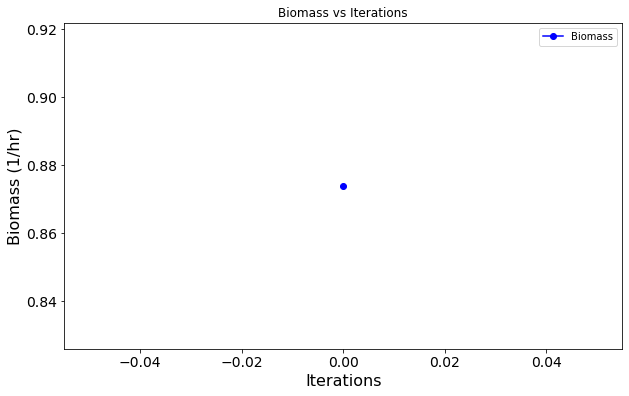

In [11]:
print("=== Step 5: Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.95
min_temperature = 0.01
max_iterations = 100
max_unchanged_iterations = 4
change_threshold = 0.009
biomass_goal = 0.5

kcat_dict, top_targets, df_new, iterations, biomasses, df_FBA = simulated_annealing(
    model=model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    objective_value=biomass_goal,
    gene_sequences_dict=gene_sequences_dict,      # ← new
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Final biomass: {biomasses[-1]:.4f}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.1f}%")
print("Top 10 enzymes by mass contribution:")
print(top_targets[['Reactions','Single_gene','enzyme_mass']])

In [12]:
# Diagnostic: After simulated annealing
print("[Step] After simulated_annealing:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After simulated_annealing:
  Genes in model: 137
  Reactions in model: 95
  First 10 gene IDs: ['b0115', 'b2415', 'b3736', 'b2463', 'b0721', 'b2492', 'b2297', 'b0474', 'b2416', 'b2287']
  First 10 reaction IDs: ['PTAr', 'ME1', 'PGK', 'G6PDH2r', 'PIt2r', 'TALA', 'ICL', 'PYK', 'GLUN', 'ATPM']
  Reactions with kcat: 66
  Reactions without kcat: 29


### Step 6: FVA

=== Step 6: Running Flux Variability Analysis ===
=== Starting FVA with enzyme constraints ===
Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpfx7un5gc.pyomo.lp
Reading time = 0.01 seconds
x1: 305 rows, 233 columns, 1035 nonzeros
Gurobi Optimizer version 10.0.1 build v10.0.1rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i7-12700, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 305 rows, 233 columns and 1035 nonzeros
Model fingerprint: 0xe837b661
Coefficient statistics:
  Matrix range     [3e-07, 4e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e-01, 1e+03]
  RHS range        [0e+00, 0e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 102 rows and 64 columns
Presolve time: 0.00s
Presolved: 203 rows,

2025-09-05 11:30:53,436 - pyomo.core - WARNING - Loading a SolverResults object with a warning status into model.name="unknown";
  - termination condition: infeasible
  - message from solver: Model was proven to be infeasible.


Optimal biomass: 0.873922
[1/95] FVA for: PFK
Maximizing flux for reaction: PFK
Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmps6yfd5ca.pyomo.lp
Reading time = 0.01 seconds
x1: 305 rows, 233 columns, 1035 nonzeros
Gurobi Optimizer version 10.0.1 build v10.0.1rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i7-12700, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 305 rows, 233 columns and 1035 nonzeros
Model fingerprint: 0x9165dbd7
Coefficient statistics:
  Matrix range     [3e-07, 4e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e-01, 1e+03]
  RHS range        [0e+00, 0e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 105 rows and 67 columns
Presolve time: 0.00s
Presolved: 200 rows, 166 columns, 7

2025-09-05 11:30:53,958 - pyomo.core - WARNING - Loading a SolverResults object with a warning status into model.name="unknown";
  - termination condition: infeasible
  - message from solver: Model was proven to be infeasible.


Minimizing flux for reaction: PFK
Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpoweqxww_.pyomo.lp
Reading time = 0.00 seconds
x1: 305 rows, 233 columns, 1035 nonzeros
Gurobi Optimizer version 10.0.1 build v10.0.1rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i7-12700, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 305 rows, 233 columns and 1035 nonzeros
Model fingerprint: 0xc15f62da
Coefficient statistics:
  Matrix range     [3e-07, 4e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e-01, 1e+03]
  RHS range        [0e+00, 0e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 105 rows and 67 columns
Presolve time: 0.01s
Presolved: 200 rows, 166 columns, 750 nonzeros

Iteration    Objective       Prim

...

2025-09-05 11:32:00,806 - pyomo.core - WARNING - Loading a SolverResults object with a warning status into model.name="unknown";
  - termination condition: infeasible
  - message from solver: Model was proven to be infeasible.


Minimizing flux for reaction: PDH
Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpvhsfzyfc.pyomo.lp
Reading time = 0.02 seconds
x1: 305 rows, 233 columns, 1035 nonzeros
Gurobi Optimizer version 10.0.1 build v10.0.1rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i7-12700, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 305 rows, 233 columns and 1035 nonzeros
Model fingerprint: 0xa982cf70
Coefficient statistics:
  Matrix range     [3e-07, 4e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e-01, 1e+03]
  RHS range        [0e+00, 0e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 105 rows and 67 columns
Presolve time: 0.00s
Presolved: 200 rows, 166 columns, 750 nonzeros

Iteration    Objective       Prim

2025-09-05 11:32:01,068 - pyomo.core - WARNING - Loading a SolverResults object with a warning status into model.name="unknown";
  - termination condition: infeasible
  - message from solver: Model was proven to be infeasible.


Reaction: PDH | Min Solution: 19.888208401328637 | Max Solution: 19.888208401328637
Reaction: PDH | Min Solution: 19.888208401328637 | Max Solution: 19.888208401328637
FVA results saved to: c:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2\notebooks\results\tuning_results\ecoli_core_20250905_5544\ecoli_core_fva_results.csv


ValueError: zero-size array to reduction operation minimum which has no identity

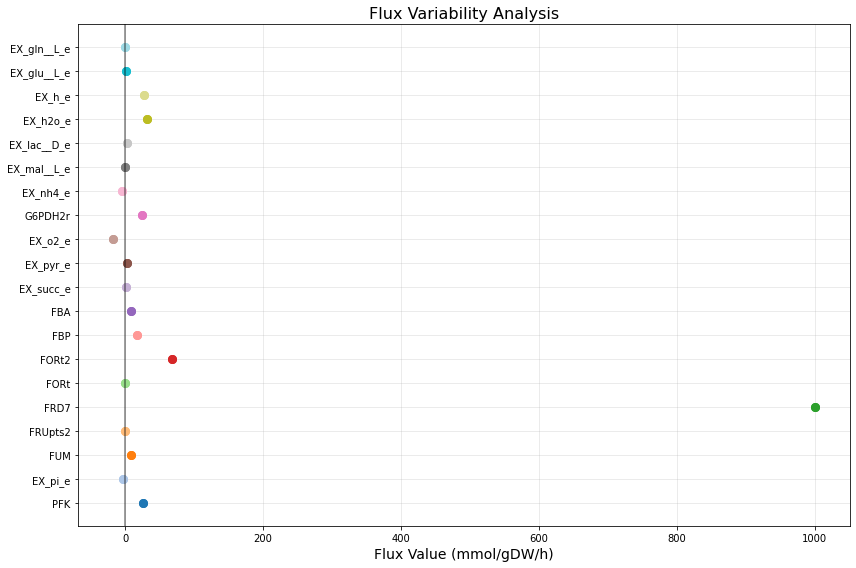

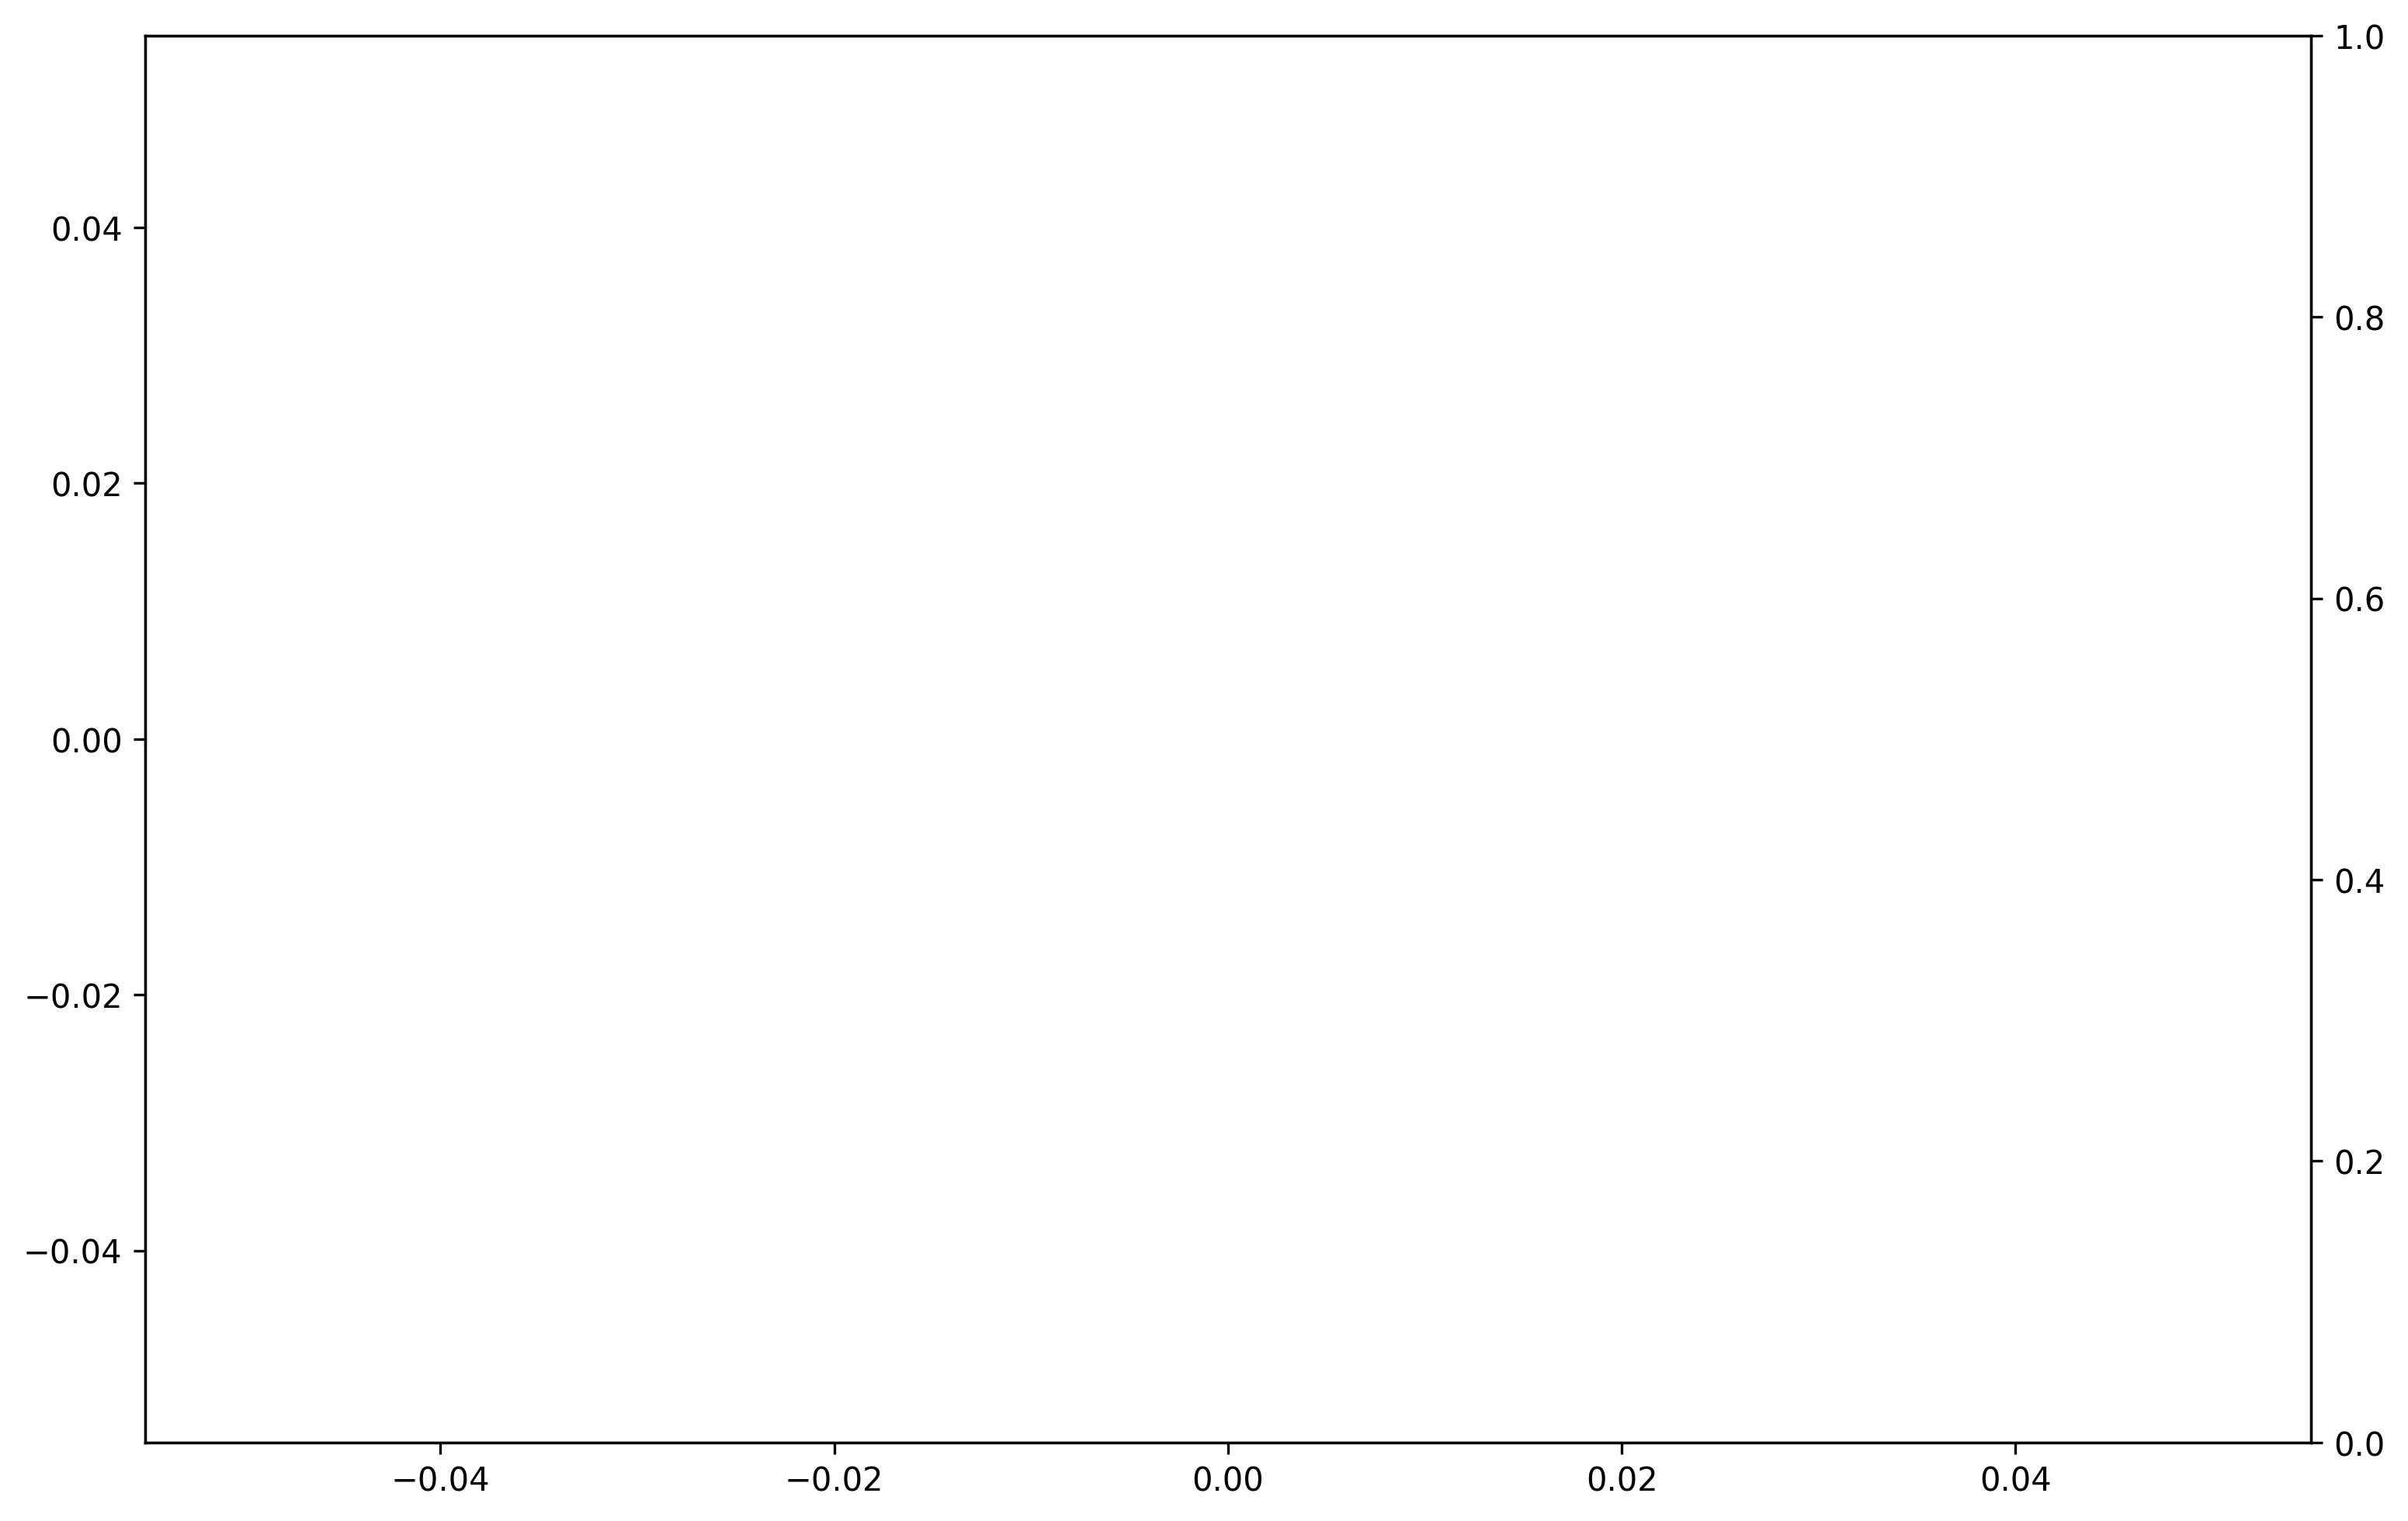

In [13]:
print("=== Step 6: Running Flux Variability Analysis ===")
fva_results_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_results.csv")
fva_plot_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_flux_range_plot.png")
fva_cumulative_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_cumulative_plot.png")

fva_results, _, _ = flux_variability_analysis(
    model=model,
    processed_df=df_new,
    biomass_reaction=biomass_reaction,
    output_file=fva_results_path,
    enzyme_upper_bound=enzyme_upper_bound
)

# Plot standard FVA range
fig = plot_flux_variability(fva_results, output_file=fva_plot_path)

# Plot cumulative distribution
plot_cumulative_fvi_distribution(
    dfs=[fva_results],
    labels=[organism_strain_GEMname],
    output_file=fva_cumulative_path
)

In [ ]:
from cobra.flux_analysis import flux_variability_analysis as cobra_fva

# Run COBRApy FVA (set fraction_of_optimum as needed, e.g. 0.9)
cobra_fva_results = cobra_fva(model, fraction_of_optimum=0.9)

# Create DataFrame in your expected format
cobra_fva_df = pd.DataFrame({
    "Reactions": cobra_fva_results.index,
    "Min Solutions": cobra_fva_results['minimum'],
    "Max Solutions": cobra_fva_results['maximum'],
    "Solution Biomass": [model.slim_optimize()] * len(cobra_fva_results)
})

In [ ]:
# Plot standard FVA range
fig = plot_flux_variability(fva_results, output_file=fva_plot_path)

# Plot cumulative distribution
plot_cumulative_fvi_distribution(
    dfs=[fva_results],
    labels=[organism_strain_GEMname],
    output_file=fva_cumulative_path
)

In [ ]:
plot_cumulative_fvi_distribution(
    dfs=[fva_results, cobra_fva_df],
    labels=["kinGEMs FVA", "COBRApy FVA"],
    output_file="cobra_fva_cumulative_plot.png"
)

### Step 7: Save Final Model

In [ ]:
# Define output path for final GEM
model_output_dir = os.path.join("models")
os.makedirs(model_output_dir, exist_ok=True)
model_output_path = os.path.join(model_output_dir, f"{run_id}.xml")

# After simulated annealing
model_with_kcats = assign_kcats_to_model(model, df_new)

# Preview:
format_kcats_like_gpr(model_with_kcats.reactions.get_by_id("PGI"))

# Diagnostic: Print problematic reaction annotations
for rxn in model_with_kcats.reactions:
    ann = rxn.annotation
    if not isinstance(ann, dict):
        print(f"Reaction {rxn.id} has non-dict annotation:", ann)
    else:
        for k, v in ann.items():
            if isinstance(v, float):
                print(f"Reaction {rxn.id} has float annotation value: {k}: {v}")
            elif isinstance(v, list) or isinstance(v, tuple):
                for item in v:
                    if isinstance(item, float):
                        print(f"Reaction {rxn.id} has float in list annotation value: {k}: {item}")
            elif not isinstance(v, (str, list, tuple, dict)):
                print(f"Reaction {rxn.id} has non-standard annotation value: {k}: {v}")

# Clean up reaction annotations before SBML export, converting float kcat values to strings
def clean_annotations(model):
    for rxn in model.reactions:
        ann = rxn.annotation
        if not isinstance(ann, dict):
            rxn.annotation = {}
        else:
            new_ann = {}
            for k, v in ann.items():
                # Convert float kcat values to strings
                if isinstance(v, float):
                    new_ann[k] = str(v)
                # Convert float elements in lists/tuples to strings
                elif isinstance(v, (list, tuple)):
                    new_ann[k] = [str(item) if isinstance(item, float) else item for item in v]
                # Keep valid types
                elif isinstance(v, (str, dict)):
                    new_ann[k] = v
                # Otherwise, skip
            rxn.annotation = new_ann
    return model

model_with_kcats = clean_annotations(model_with_kcats)

# Save the final irreversible model
write_sbml_model(model_with_kcats, model_output_path)

print(f"Final GEM saved to: {model_output_path}")

Final GEM saved to: ../models\ecoli_core_20250515_8518.xml


: 

In [ ]:
# Diagnostic: After saving final model
print("[Step] After saving final model (assign_kcats_to_model + clean_annotations):")
print("  Genes in model_with_kcats:", len(model_with_kcats.genes))
print("  Reactions in model_with_kcats:", len(model_with_kcats.reactions))
model_gene_ids = set([g.id for g in model_with_kcats.genes])
model_rxn_ids = set([r.id for r in model_with_kcats.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model_with_kcats.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

In [ ]:
print("Genes in loaded model:", len(model_with_kcats.genes))

In [ ]:
# Diagnostic: Track kcat annotation coverage and optimization usage
def get_kcat_coverage(model):
    rxn_with_kcat = []
    rxn_without_kcat = []
    for rxn in model.reactions:
        ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
        # Check for kcat in annotation (adjust key as needed)
        if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
            rxn_with_kcat.append(rxn.id)
        else:
            rxn_without_kcat.append(rxn.id)
    return rxn_with_kcat, rxn_without_kcat

rxn_with_kcat, rxn_without_kcat = get_kcat_coverage(model_with_kcats)
print(f"Total reactions in model: {len(model_with_kcats.reactions)}")
print(f"Reactions with kcat values: {len(rxn_with_kcat)}")
print(f"Reactions without kcat values: {len(rxn_without_kcat)}")
print(f"First 10 reactions with kcat: {rxn_with_kcat[:10]}")
print(f"First 10 reactions without kcat: {rxn_without_kcat[:10]}")

# If you want to check which reactions were used in optimization,
# you can print the reactions in df_new (from simulated annealing)
if 'df_new' in locals():
    print(f"Reactions in optimization results (df_new): {len(df_new['Reactions'].unique())}")
    print(f"First 10 reactions in optimization: {df_new['Reactions'].unique()[:10]}")